In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandahouse as ph
from statsmodels.tsa.seasonal import STL

In [2]:
connection = {
    'host': 'https://clickhouse.lab.karpov.courses',
    'password': 'dpo_python_2020',
    'user': 'student',
    'database': 'simulator'
}

In [3]:
q_timeseries = """
SELECT toStartOfHour(time) as ts,
       count() as actions
FROM simulator_20250520.feed_actions
GROUP BY ts
ORDER BY ts
"""
hourly_activity = ph.read_clickhouse(q_timeseries, connection=connection)

hourly_activity = hourly_activity.set_index('ts')

print("Почасовая динамика активности:")
print(hourly_activity.head())

Почасовая динамика активности:
                     actions
ts                          
2025-04-05 00:00:00       22
2025-04-05 01:00:00       32
2025-04-05 02:00:00       24
2025-04-05 03:00:00       11
2025-04-05 04:00:00       18


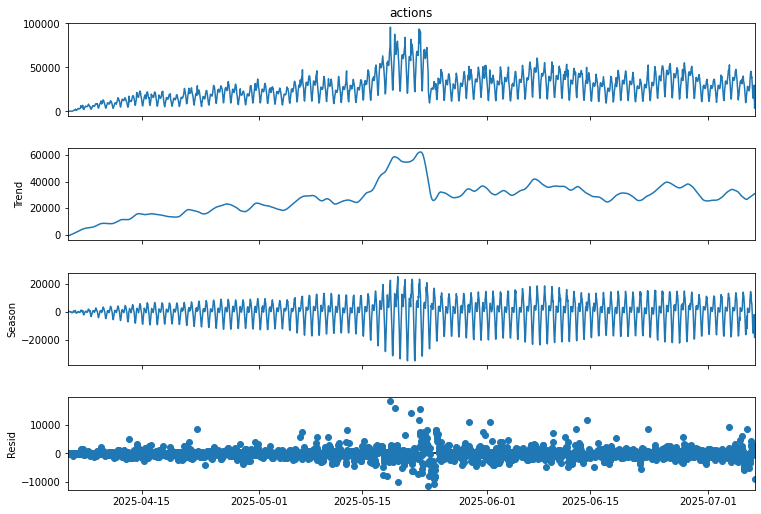

In [4]:
stl = STL(hourly_activity['actions'], period=24)
result = stl.fit()

fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()